In [46]:
library(xgboost)
library(lime)

# Load necessary libraries
library(caret)
library(pROC)  # For AUC-ROC calculation


In [53]:
scaled_df = read.csv('../data/merged_dataset.csv')
meta = read.csv('../data/merged_dataset_meta.csv')
response_name = 'cluster'

# became_data = scaled_df[rownames(subset(meta,cohort=='BECAME')),]

became_data = scaled_df
became_meta = meta[rownames(became_data),]
became_data$response_var = as.factor(as.numeric(became_meta[rownames(became_data),response_name]=='B1'))


In [54]:
# Example: Train an XGBoost classifier

index <- createDataPartition(became_data$response_var, p = 0.7, list = FALSE)

X <- became_data[index,grepl('^X',colnames(became_data))]
y <- as.numeric(as.character(became_data[index,]$response_var))

dtrain <- xgb.DMatrix(data = as.matrix(X), label = y)

# Set parameters
params <- list(
  objective = "binary:logistic",
  eval_metric = "logloss"
)

# Train the XGBoost model
model <- xgboost(data = dtrain, 
                 params = params, 
                 nrounds = 50)


[1]	train-logloss:0.458207 
[2]	train-logloss:0.324183 
[3]	train-logloss:0.238886 
[4]	train-logloss:0.178003 
[5]	train-logloss:0.135288 
[6]	train-logloss:0.104436 
[7]	train-logloss:0.081763 
[8]	train-logloss:0.065440 
[9]	train-logloss:0.052313 
[10]	train-logloss:0.043357 
[11]	train-logloss:0.036667 
[12]	train-logloss:0.030680 
[13]	train-logloss:0.026260 
[14]	train-logloss:0.022943 
[15]	train-logloss:0.020282 
[16]	train-logloss:0.018145 
[17]	train-logloss:0.016840 
[18]	train-logloss:0.015313 
[19]	train-logloss:0.014357 
[20]	train-logloss:0.013267 
[21]	train-logloss:0.012598 
[22]	train-logloss:0.012005 
[23]	train-logloss:0.011466 
[24]	train-logloss:0.010990 
[25]	train-logloss:0.010548 
[26]	train-logloss:0.010151 
[27]	train-logloss:0.009758 
[28]	train-logloss:0.009389 
[29]	train-logloss:0.009086 
[30]	train-logloss:0.008803 
[31]	train-logloss:0.008555 
[32]	train-logloss:0.008552 
[33]	train-logloss:0.008550 
[34]	train-logloss:0.008548 
[35]	train-logloss:0.00

In [55]:
importance <- xgb.importance(model = model)
print(importance)


    Feature         Gain       Cover  Frequency
 1:     X37 0.2322533827 0.144154285 0.04285714
 2:     X62 0.1685436282 0.152533192 0.12857143
 3:     X71 0.1289141111 0.138532010 0.08571429
 4:     X82 0.0633314253 0.107974163 0.02857143
 5:     X51 0.0614342171 0.018573465 0.07142857
 6:      X3 0.0494262535 0.031241722 0.07142857
 7:      X5 0.0492280915 0.060177983 0.10000000
 8:    X128 0.0424443592 0.021456463 0.07142857
 9:     X78 0.0367983712 0.007639620 0.02857143
10:     X61 0.0283370692 0.052838192 0.01428571
11:     X38 0.0276613826 0.044542867 0.01428571
12:     X84 0.0225550179 0.045997367 0.05714286
13:     X94 0.0218025856 0.013352865 0.07142857
14:     X41 0.0196364356 0.003225640 0.01428571
15:    X160 0.0140355004 0.006456848 0.01428571
16:     X60 0.0129335559 0.006017121 0.02857143
17:    X114 0.0061019290 0.043374157 0.01428571
18:     X65 0.0048943798 0.004525809 0.02857143
19:      X6 0.0021118858 0.055828385 0.01428571
20:    X144 0.0020366482 0.002031402 0.0

In [35]:
threshold <- 0.01  # Adjust as needed
selected_features <- importance$Feature[importance$Gain >= threshold]
X_selected <- X[, selected_features]


In [56]:
# Create an explainer with lime
explainer <- lime(X, model, bin_continuous = FALSE)
became_meta_train = became_meta[index,]
order_features = colnames(X)

out = data.frame()
for(i in 1:nrow(X)){
    
    # Choose an instance to explain
    instance_to_explain <- X[i, , drop = FALSE]

    label_name = as.character(as.numeric(became_meta_train[i,response_name] == 'B1'))
    
    # Explain the instance
    explanation <- explain(instance_to_explain,explainer, 
                           labels=label_name, 
                           n_features=161)
    weights = explanation$feature_weight
    names(weights) = explanation$feature
    
    out = rbind(out,weights[order_features])
}

rownames(out) = rownames(X)
colnames(out) = order_features

In [57]:
head(out)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,⋯,X152,X153,X154,X155,X156,X157,X158,X159,X160,X161
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
X10302,-0.0002315066,4.326324e-05,-0.002792134,1.646627e-04,0.003235456,0.0007955535,-0.0003062158,6.963073e-06,9.534357e-05,-3.136387e-04,⋯,-1.419326e-04,-1.081314e-03,-1.156617e-04,-3.834274e-04,0.0003657339,-2.347156e-04,5.582558e-04,9.166273e-05,9.371670e-04,-3.852886e-04
X10303,0.0006192352,-3.704618e-04,-0.003077614,6.950932e-05,0.003071582,0.0002371199,-0.0006703857,-4.961234e-04,-1.863778e-04,-4.240087e-04,⋯,1.686071e-04,-2.221502e-04,4.207055e-05,-4.898675e-04,0.0004218992,3.062155e-04,-1.128489e-04,4.689466e-04,-2.078079e-05,-1.288738e-04
X10304,0.0002642819,-2.174637e-04,0.003699694,-9.828224e-05,-0.002178108,-0.0009643771,-0.0002652924,-2.215482e-04,-1.474423e-04,6.393289e-04,⋯,2.893183e-04,5.819427e-05,3.072629e-04,6.741614e-06,0.0002024653,-4.230234e-04,6.056848e-04,-6.441894e-04,-6.510688e-04,3.341474e-04
X10306,0.0007348248,2.907788e-05,-0.003920823,-6.633323e-04,0.003948037,0.0006517089,0.0001897161,-3.020530e-04,-2.005391e-04,2.375766e-05,⋯,1.423027e-04,4.351027e-04,3.185441e-04,2.002354e-04,0.0004922097,-2.667508e-04,2.442245e-04,2.296641e-04,3.404128e-04,7.604572e-05
X10309,0.0004929396,1.481820e-04,-0.003835008,2.665853e-04,0.003301953,0.0003527002,0.0004040608,-1.354227e-04,-1.919928e-04,7.553809e-05,⋯,-8.420215e-05,5.398067e-04,4.033324e-04,-4.695944e-04,-0.0008370146,2.686774e-05,1.859317e-04,4.769150e-04,9.313014e-04,5.510427e-04
X10310,0.0003340750,-2.512841e-04,-0.004448313,-3.301892e-04,0.003500981,-0.0003909505,-0.0003063223,-3.717603e-04,5.398259e-04,-1.165539e-04,⋯,1.691061e-04,2.543718e-04,8.429141e-04,2.441436e-04,-0.0001950300,-6.590424e-04,1.030964e-05,-1.166462e-04,8.171225e-04,6.692108e-09


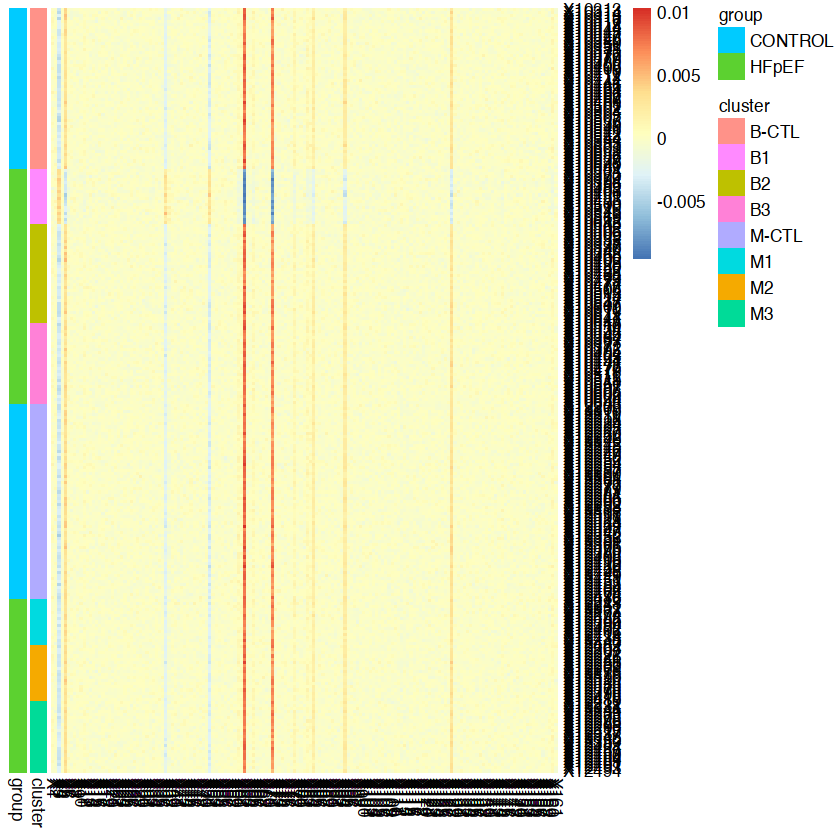

In [59]:
pheatmap::pheatmap(na.omit(out[rownames(became_meta[order(became_meta$cluster),]),]),
                   cluster_row=F,cluster_col=F,annotation_row=became_meta[rownames(became_meta[order(became_meta$cluster),]),c('cluster','group')])

Confusion Matrix and Statistics

          Reference
Prediction  0  1
         0 96  3
         1  1  4
                                          
               Accuracy : 0.9615          
                 95% CI : (0.9044, 0.9894)
    No Information Rate : 0.9327          
    P-Value [Acc > NIR] : 0.1636          
                                          
                  Kappa : 0.6469          
                                          
 Mcnemar's Test P-Value : 0.6171          
                                          
            Sensitivity : 0.9897          
            Specificity : 0.5714          
         Pos Pred Value : 0.9697          
         Neg Pred Value : 0.8000          
             Prevalence : 0.9327          
         Detection Rate : 0.9231          
   Detection Prevalence : 0.9519          
      Balanced Accuracy : 0.7806          
                                          
       'Positive' Class : 0               
                                    

Setting levels: control = 0, case = 1

Setting direction: controls < cases



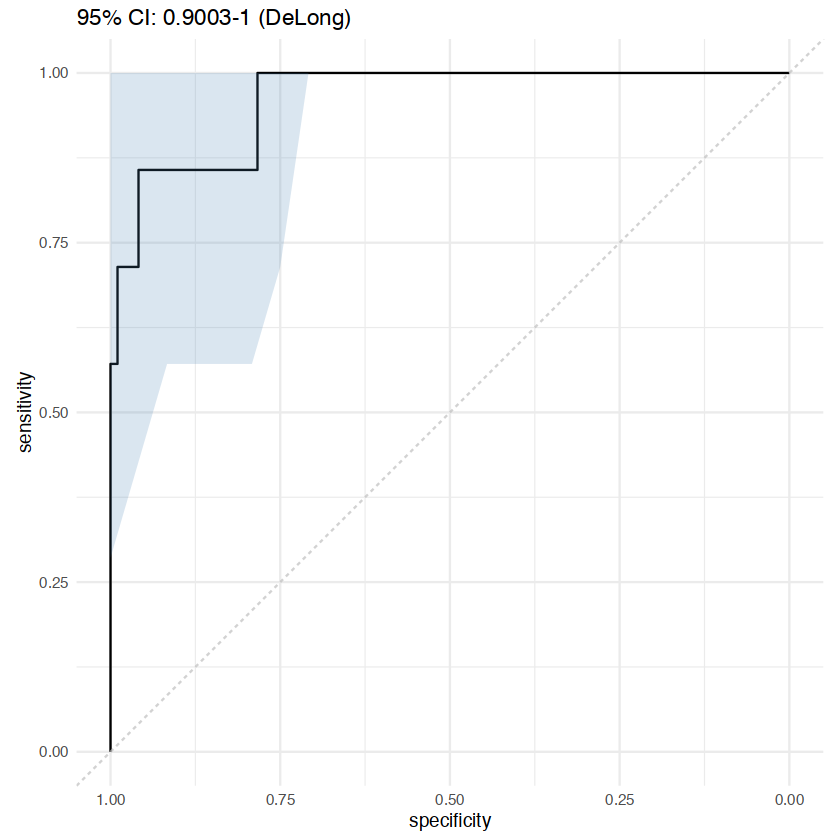

In [60]:
X_test <- became_data[-index,grepl('^X',colnames(became_data))]
y_test <- factor(as.numeric(as.character(became_data[-index,]$response_var)))

# Predictions on the test set
predictions <- predict(model, as.matrix(X_test))

# Convert predicted probabilities to class labels (binary classification)
predicted_labels <- ifelse(predictions > 0.5, 1, 0)

# Confusion matrix
conf_matrix <- confusionMatrix(factor(predicted_labels), y_test)
print(conf_matrix)

# Accuracy
accuracy <- conf_matrix$overall["Accuracy"]
print(paste("Accuracy:", accuracy))

# Precision, Recall, and F1-Score
precision <- conf_matrix$byClass["Precision"]
recall <- conf_matrix$byClass["Recall"]
f1_score <- conf_matrix$byClass["F1"]

print(paste("Precision:", precision))
print(paste("Recall:", recall))
print(paste("F1-Score:", f1_score))


obj <- roc(y_test, predictions, ci=TRUE, plot=FALSE)
ciobj <- ci.se(obj, specificities=seq(0, 1, l=25))
dat.ci <- data.frame(x = as.numeric(rownames(ciobj)),
                     lower = ciobj[, 1],
                     upper = ciobj[, 3])

proc = ggroc(obj) + 
    theme_minimal() + 
    geom_abline(slope=1, intercept = 1, linetype = "dashed", alpha=0.7, color = "grey") + 
    coord_equal() + 
    geom_ribbon(data = dat.ci, aes(x = x, ymin = lower, ymax = upper), fill = "steelblue", alpha= 0.2) + 
    ggtitle(capture.output(obj$ci))

proc

